# Image segmentation with the U-Net model

## Installing depencencies

In [1]:
%pip install opencv-python matplotlib scikit-image scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

## Dataset Path

In [3]:
DATASET_PATH = Path("../dataset/images")

## Loading dataset

In [4]:
image_paths = []

for cls in DATASET_PATH.iterdir():

    if cls.is_dir():

        for image in cls.glob("*"):

            if image.suffix.lower() in [".jpg", ".jpeg", ".png"]:

                image_paths.append(image)


print("Total Images: ", len(image_paths))

Total Images:  1156


## Display Image

(np.float64(-0.5), np.float64(309.5), np.float64(3833.5), np.float64(-0.5))

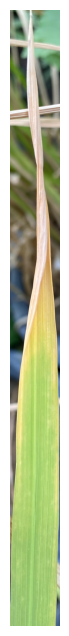

In [5]:
image = cv2.imread(str(image_paths[0]))

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.axis("off")

## Applying Grabcut

In [6]:
def grabcut_leaf(image,
                 margin=10,
                 iterations=5):

    mask = np.zeros(image.shape[:2], np.uint8)

    bgdModel = np.zeros((1,65),np.float64)

    fgdModel = np.zeros((1,65),np.float64)

    rect = (
        margin,
        margin,
        image.shape[1]-2*margin,
        image.shape[0]-2*margin
    )

    cv2.grabCut(
        image,
        mask,
        rect,
        bgdModel,
        fgdModel,
        iterations,
        cv2.GC_INIT_WITH_RECT
    )

    binary = np.where(
        (mask==2)|(mask==0),
        0,
        1
    ).astype("uint8")

    leaf = image * binary[:,:,np.newaxis]

    return leaf,binary

## Test Grabcut

In [7]:
leaf,mask = grabcut_leaf(image)

## Visualize

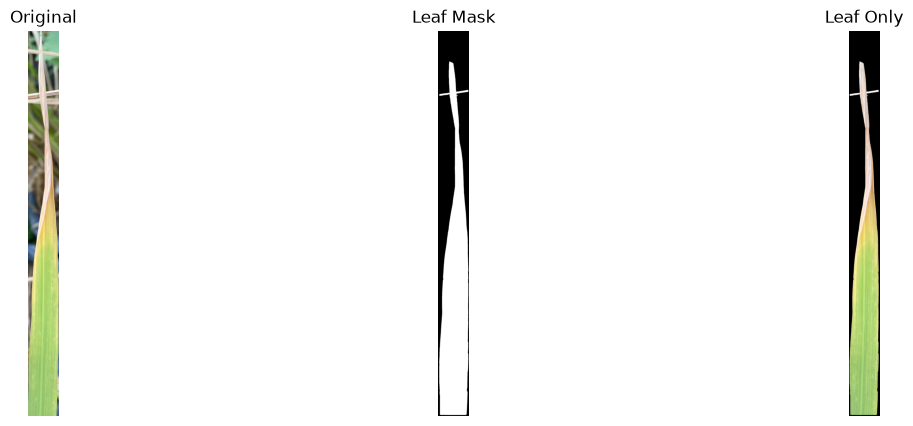

In [8]:
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(mask,cmap="gray")
plt.title("Leaf Mask")
plt.axis("off")

plt.subplot(133)
plt.imshow(cv2.cvtColor(leaf,cv2.COLOR_BGR2RGB))
plt.title("Leaf Only")
plt.axis("off")

plt.show()

## Applying CLAHE

In [9]:
def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE to the L channel of the Lab color space.
    """

    # Convert BGR to Lab
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # Split channels
    l, a, b = cv2.split(lab)

    # Create CLAHE object
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    # Apply CLAHE to L channel
    l = clahe.apply(l)

    # Merge channels
    lab = cv2.merge((l, a, b))

    # Convert back to BGR
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    return enhanced

## Usage of CLAHE

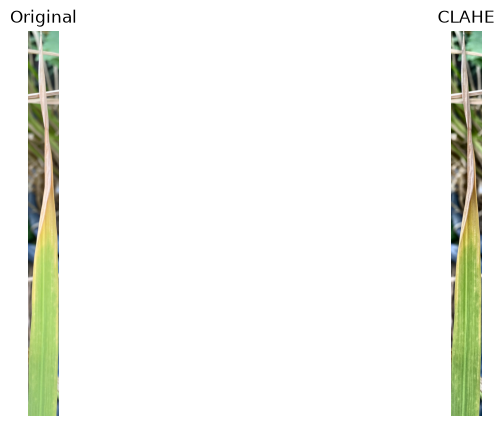

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

enhanced = apply_clahe(image)

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
plt.title("CLAHE")
plt.axis("off")

plt.show()

- Convert the CLAHE-enhanced leaf to Lab.
- Reshape pixels into an N × 3 array.
- Run cv2.kmeans() or sklearn.cluster.KMeans.
- Reconstruct the clustered image.
- Visualize each cluster.
- Select the cluster(s) corresponding to nutrient deficiency.
- Generate a binary disease mask.

In [11]:
def kmeans_segmentation(image, k=3):

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    pixels = lab.reshape((-1, 3)).astype(np.float32)

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        100,
        0.2
    )

    _, labels, centers = cv2.kmeans(
        pixels,
        k,
        None,
        criteria,
        10,
        cv2.KMEANS_PP_CENTERS
    )

    labels = labels.reshape(lab.shape[:2])

    return labels, centers

## Testing classification

In [12]:
leaf, _ = grabcut_leaf(image)

enhanced = apply_clahe(leaf)

labels, centers = kmeans_segmentation(enhanced)

## Selecting disease cluster

In [13]:
def select_disease_cluster(labels, centers):

    scores = []

    for center in centers:

        L, A, B = center

        score = B + 0.5*A

        scores.append(score)

    disease_cluster = np.argmax(scores)

    mask = (labels == disease_cluster).astype(np.uint8)

    return mask

## Refining Masks

In [14]:
def refine_mask(mask, kernel_size=5, min_area=200):

    kernel = np.ones((kernel_size, kernel_size), np.uint8)

    # Opening
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # Closing
    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Smooth
    mask = cv2.medianBlur(mask.astype(np.uint8),5)

    # Connected Components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

    refined = np.zeros_like(mask)

    for i in range(1, num_labels):

        if stats[i, cv2.CC_STAT_AREA] > min_area:

            refined[labels == i] = 1

    return refined

## Processing function per image

In [15]:
def process_image(image_path):

    image = cv2.imread(str(image_path))

    # Step 1
    leaf, leaf_mask = grabcut_leaf(image)

    # Step 2
    enhanced = apply_clahe(leaf)

    # Step 3
    labels, centers = kmeans_segmentation(enhanced)

    # Step 4
    disease_mask = select_disease_cluster(labels, centers)

    # Step 5
    disease_mask = refine_mask(disease_mask)

    return disease_mask

## Complete process to calculate masks

In [ ]:
from pathlib import Path
from tqdm import tqdm

DATASET_DIR = Path("../dataset/images")
OUTPUT_DIR = Path("../dataset/masks")

OUTPUT_DIR.mkdir(exist_ok=True)

for class_folder in DATASET_DIR.iterdir():

    if not class_folder.is_dir():
        continue

    output_class = OUTPUT_DIR / class_folder.name
    output_class.mkdir(parents=True, exist_ok=True)

    print(f"\nProcessing {class_folder.name}")

    for image_path in tqdm(class_folder.glob("*")):

        if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        mask = process_image(image_path)

        save_path = output_class / (image_path.stem + ".png")

        cv2.imwrite(str(save_path), mask * 255)


Processing nitrogen


0it [00:00, ?it/s]

440it [36:00,  4.91s/it]



Processing phosphorous


333it [2:19:46, 25.19s/it]



Processing potassium


314it [2:24:23, 54.90s/it]